In [ ]:
import pandas as pd
import numpy as np

In [ ]:
vendas = pd.read_csv('01.amazon_sales_dataset.csv')
vendas.columns

In [ ]:
vendas.dtypes

In [ ]:
vendas.info()

In [ ]:
total_vendas = vendas['total_sales'].sum()
media_valor_vendas = vendas['total_sales'].mean()
vendas_minima = vendas['total_sales'].min()
venda_maxima  = vendas['total_sales'].max()



In [ ]:
print('\n--- Resumo executivo de vendas ---')
print(f'1. Volume total (Soma das vendas): $ {total_vendas:,.2f}')
#representa o tamanho total da nossaa operação no periodo 
print(f'2. Gastos Médios: $ {media_valor_vendas:,.2f}')
# valor esperado que um cliente gaste em média conosco 
print(f'3. Maior venda: $ {venda_maxima:,.2f}')
# Nosso recorde. Investigar o perfil do clinte 
print(f'4. Menor venda: $ {vendas_minima:,.2f}')
# Menor valor registrado. Investigar anomalias ou fraude 
print(30 * '-')

In [ ]:
#Soma de vendas por categoria
vendas.groupby('category')['total_sales'].sum()

In [ ]:
#Média de vendas por categoria
vendas.groupby('category')['total_sales'].mean()

In [ ]:
#Maior venda por categoria
vendas.groupby('category')['total_sales'].max()

In [ ]:
#Menor venda por categoria
vendas.groupby('category')['total_sales'].min()

In [ ]:
#Várias análises juntas (mais profissional 👩‍💻✨)
vendas.groupby('category')['total_sales'].agg(['sum', 'mean', 'max', 'min'])

In [ ]:
#Se quiser ordenar da maior venda para menor
vendas.groupby('category')['total_sales'].sum().sort_values(ascending=False)

In [ ]:
#EXTRA (Muito bom para trabalho escolar)
vendas.groupby('category')['quantity'].sum()

In [ ]:
#GRAFICO
#Primeiro: gerar os dados agrupados
import matplotlib.pyplot as plt

vendas_categoria = vendas.groupby('category')['total_sales'].sum()

In [ ]:
#2️⃣ Criar o gráfico de barras
plt.figure()
vendas_categoria.plot(kind='bar')

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas')

plt.show()

In [ ]:
#Se quiser deixar mais organizado (ordenado)

vendas_categoria = vendas.groupby('category')['total_sales'].sum().sort_values()

plt.figure()
vendas_categoria.plot(kind='bar')

plt.title('Total de Vendas por Categoria')
plt.xlabel('Categoria')
plt.ylabel('Total de Vendas')

plt.show()

In [ ]:
import pandas as pd
import numpy as np
df_vendas = pd.read_csv('01.amazon_sales_dataset.csv')
df_vendas.columns

In [ ]:
df_vendas.dtypes

In [ ]:
df_vendas.info()

In [ ]:
# medidas de tendencias centrais  posicoes 
coluna_alvo = 'total_sales'
total_vendas = df_vendas [coluna_alvo].sum()
media_valor_vendas = df_vendas [coluna_alvo].mean()
venda_minima = df_vendas [coluna_alvo].min()
venda_maxima = df_vendas [coluna_alvo].max()

In [ ]:
# medidas de posicao
q1 = np.percentile (df_vendas [coluna_alvo], 25)
# q2 = mediana
q2 = np.percentile (df_vendas [coluna_alvo], 50)
q3 = np.percentile (df_vendas [coluna_alvo], 75)

In [ ]:
# avalias a 'confiabilidade da media'
delta_media_mediana = media_valor_vendas - q2
distancia_percentual = media_valor_vendas/q2 
# distancia <= 10% (0.9 ~ 1.1)
# media é altamente confiavel
# caso 2. distancia entre 10% e 25% (0.75 ~ 0.9 / 1.10~1.25)
# R media sofre influenia moderada de extremos 
# caso 3. distancia > 25% (< 0.75 / 1.25)
# R = nao confie na media, ela é distorcida
# pelos extremos
# assimetria (skewness)



In [ ]:
plt.boxplot([q1, q2, q3])

In [ ]:
# Medias de disperção

# 1. Amplitude 

amplitude = venda_maxima - venda_minima
print('Amplitude:', amplitude)
print('\n*******************')
#2. Variancia e desvio padrão
# medem a distancia média dos pontos da média
# se fo um valor alto -> maior volatilidade

variancia = df_vendas[coluna_alvo].var()
desvio_padao = df_vendas[coluna_alvo].std()
print('Variancia:', variancia)
print('\n*******************')
print('Desvio padrao:', desvio_padao)
# 3. IQR -> 50% 'internos' dos dados (25%~75%)
#Muito robusto a ouliers
iqr = q3 - q1
print('IQR:', iqr)
print('\n*******************')


# 4. Coeficiente da variação (CV)
# Muuito usado para comparar volatilidades de 'grandezas' diferentes(colunas diferentes)
#obs.: Multiplicado por 100 para ser descrito como porcentagem 

cv = (desvio_padao/media_valor_vendas)*100
print('Coeficiente de variação:', cv, '%')


In [ ]:
# Assimetria # Assimetria (Skewness)
assimetria = df_vendas[coluna_alvo].skew()

# Caso 1. Assimetria entre -0.5 e 0.5
# R = Dados Equilibrados
# Caso 2. Assimetria > 0.5 (Positiva)
# R = Valores altos são raros, porém são tão
# grandes que distorcem o calculo
# Caso 3. Assimetria < - 0.5 (Negativa)
# R = Menos valores distorcem o calculo para baixo

# Curtose(Kurtosis) , mede o peso das caldas -> frequencia e gravidade das outlers

curtose = df_vendas[coluna_alvo].kurtosis()
print('Curtose:', curtose)

print('\n--- Resumo Executivo de Vendas ---')
print(f'1. Volume Total (Soma das Vendas): \
      $ {total_vendas:,.2f}')
# Representa o tamanho total da nossa operação no periodo
print(f'2. Gasto Médio: $ {media_valor_vendas:,.2f}')
# Valor esperado que um cliente gaste em média conosco
print(f'3. Maior Venda: $ {venda_maxima:,.2f}')
# Nosso recorde. Investigar o perfil do cliente
print(f'4. Menor Venda: $ {venda_minima:,.2f}')
# Menor valor registrado. Investigar se há anomalias ou fraude

In [ ]:
print('--- relatorio estatisticos de negocio ---')

print(f'a media de vendas é: $ {media_valor_vendas:,.2f}') 
print('a mediana (valor central) das vendas é {q2}')
print(f'o delta (diferença financeira) entre elas é: $ {delta_media_mediana:,.2f}') 
print('\n--- analise comportametal ---\n')
print(f'Distancia Relativa entre elas: \
       {distancia_percentual}')
print(f'grau de assimetria(skewness): \
      {assimetria}')


In [ ]:
if abs (distancia_percentual) < 0.10:
      print(f'INFERÊNCIA: baixa dispersão a media é confiavel para representar a coluna ')
elif abs(distancia_percentual) < 0.25:
      print(f'INFERÊNCIA: dispersão moderada. fique atento a valores extremos, media começa a mentir.')
      
            
df_vendas = pd.read_csv('01.amazon_sales_dataset.csv')
df_vendas.columns

In [ ]:
print('--- Relatorio Estatísticos de Negócio ---')

print(f'A média de vendas é \
      $ {media_valor_vendas:,.2f}')
print(f'A mediana (valor central) das vendas é \
      $ {q2:,.2f}')
print(f'O Delta (Diferença Financeira) entre \
      elas é: $ {delta_media_mediana:,.2f}')

print('\n--- Analise Comportamental ---\n')
print(f'Distância Relativa entre elas: \
      {distancia_percentual:.2f}')


if abs(distancia_percentual) < 0.10:
      print(f'INFERÊNCIA: Baixa Dispersão. \
            A média é confiável para representar a coluna.')

elif abs(distancia_percentual) < 0.25:
      print(f'INFERÊNCIA: Dispersão Moderada. \
            Fique atento aos extremos, média começa a mentir.')
      
else:
      print(f'INFERÊNCIA: Alta Dispersão. \
            A média NÃO é confiável, foque na mediana.')

print(f'Grau de Assimetria (Skewness): \
      {assimetria:.4f}')

if assimetria > 0.5:
    print(f'INFERÊNCIA (Assimetria Positiva): \
            Nossas vendas tem uma cauda longa para a direita.\
            Os grandes clientes são minoria, todavia eles \
            faturam valores expressivos \
            puxando a venda média para cima')
elif assimetria < -0.5:
    print(f'INFERÊNCIA (Assimetria Negativa): \
            Nossa vendas tem uma cauda longa para a esquerda.\
            O valor médio está sendo puxado para baixo por um \
            grande volume de vendas baratas, \
            talvez pela liquidação')
else:
    print(f'INFERÊNCIA (Simétrica): Distribuição Equilibrada.\
          Média e mediana estão bem próximas.')



In [ ]:
# Amplitude no Negocio: diferença entre a maior e menor vendas 
print(f'Amplitude: $ {amplitude:,.2f}')
print(f'Variancia: $ {variancia:,.2f}')
# Desvio no negocio : Nivel de disperção dos valores de vendas 
print(f'Desvio padrao: $ {desvio_padao:,.2f}')
print(f'Intervalo Interquartil (IQR): $ {iqr:,.2f}')
print('INFERÊNCIA: Esta é a variação de gastos do nosso consumidor padrão, ignorando clientes que compram muito pouco ou muito caro.')
print(f'Coeficiente de variação: {cv:.2f}%')
if cv > 30:
    print('INFERÊNCIA: Volatilidade Alta. Não há consistencia no faturamento diario')
else:
    print('INFERÊNCIA: Volatilidade baixa. Vendas são consistentes e previsíveis.')
# Curtose -> Curva Normal(Curtose = 3)
# Curtose no Pandas -> Já tratado excesso  sobre a curva normal
# No panda Krutosis() = 0 -> Mesocúrtica
print(f'Curtose (Execesso - Fisher): {curtose:.4f}')
if curtose > 0.5:
    print('INFERÊNCIA: Distribuição (Curva) Leptocúrtica (mais afilada que a normal, pico agudo), cauda mais pesada que a normal(caudas grossas)')
    print('Sobre o negócio: A maioria das vendas estão no centro da distribuição, indicando comportamento mais previsível e consistente. Todavia temos uma altissima propabilidade de vendas extremas.(outliers)')
elif curtose < -0.5:
    print('INFERÊNCIA: Distribuição (Curva) Platicúrtica (mais achatada que a normal, pico mais baixo),cauda mais leve que a normal(caudas finas)')
    print('Sobre o negócio: A maioria das vendas estão bem distribuídas, indicando comportamento menos previsível e consistente. Todavia temos uma baixa probabilidade de vendas extremas.(outliers)')
else:
    print('INFERÊNCIA: Distribuição (Curva) Mesocúrtica (similar à normal, pico médio), cauda similar à normal(caudas normais)')
    print('Sobre o negócio: A maioria das vendas estão bem distribuídas, indicando comportamento mais previsível e consistente.')



In [ ]:
# Navegação e filtros Avançados 
# iloc -> pega'n' linhas ->

amostra = df_vendas.iloc[0:10]
amostra

In [ ]:
# loc -> usa nome da coluna e filta com abase em algo

# quem são os melhores clientes?

clientes_vip = df_vendas.loc[df_vendas['total_sales']> q3]
clientes_vip
print('\n --------------')
clientes_vip2 = df_vendas.loc[df_vendas['total_sales'] > q3, ['order_id','customer_name','category','total_sales', ]]
clientes_vip2






In [ ]:
# query (Consulta)
# O gerente quer saber quais pedidos da categotia eletronico
# ficaram acima da média geral

filtro = f"category == 'Eletronics' and total_sales > {media_valor_vendas}"
eletronicos = df_vendas.query(filtro)
eletronicos 

In [ ]:
# query (Consulta)
# O gerente quer saber quais pedidos da categotia eletronico
# ficaram acima da média geral

filtro = f"category == 'Eletronics' and total_sales > {media_valor_vendas}"
eletronicos = df_vendas.query(filtro)
eletronicos 

In [ ]:
#de_vendas é a sua base
# agrupar por qual coluna? category
# O que iremos calcula? total_sales
#O que iremos calcular?

df_categoria_agrupada = df_vendas.groupby('category')['total_sales'].sum().reset_index()
df_categoria_ordenada = df_categoria_agrupada.sort_values(by='total_sales', ascending=False)

print(f'Categoria ordenada: {df_categoria_ordenada.round(2)}')

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
plt.plot(df_categoria_ordenada['category'], df_categoria_ordenada['total_sales'])

In [ ]:
plt.figure()
df_categoria_ordenada.plot(x='category', y='total_sales', kind='bar')

plt.title('Total de Vendas por Categoria')
plt.xlabel('Category')
plt.ylabel('Total_sales')

plt.show()

In [ ]:
plt.hist(df_vendas['total_sales'], bins=10)

In [ ]:
plt.scatter(q1, q2)

In [ ]:
plt.boxplot(df_categoria_agrupada['total_sales'])
plt.title('Total de Vendas por Categoria')

<BarContainer object of 3 artists>

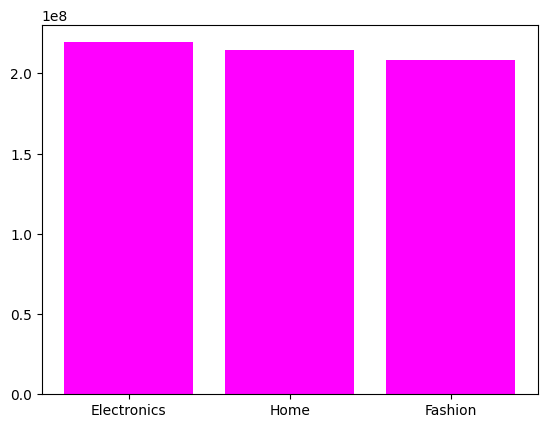

In [187]:
plt.bar(df_categoria_ordenada['category'], df_categoria_ordenada['total_sales'],color='magenta')